In [1]:
!pip install tensorflow
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Lambda
import random
from tensorflow.keras.optimizers import Adam

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Parameters
IMAGE_SIZE = (224, 224)  # Resize all images to 224x224 for VGG16
NUM_CLASSES = 72  # Number of character classes
SUPPORT_SIZE = 5  # Support set size per class
QUERY_SIZE = 15   # Query set size per class
TOTAL_IMAGES = 20  # Total images per class
DATA_PATH = '/content/drive/MyDrive/new dataset'  # Update with your dataset path

# Load the data
def load_images(data_path, img_size):
    images = []
    labels = []
    class_names = os.listdir(data_path)
    for idx, class_name in enumerate(class_names):
        class_dir = os.path.join(data_path, class_name)
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
            img_array = tf.keras.preprocessing.image.img_to_array(img)
            images.append(img_array)
            labels.append(idx)
    return np.array(images), np.array(labels), class_names

images, labels, class_names = load_images(DATA_PATH, IMAGE_SIZE)
images = images / 255.0  # Normalize images to [0, 1]

# Split data into training and testing sets
train_images, test_images, train_labels, test_labels = train_test_split(images, labels, test_size=0.2, stratify=labels)


In [4]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, GlobalAveragePooling2D
from tensorflow.keras.models import Model

def create_embedding_model(input_shape):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # We don't want to train VGG16 layers
    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    model = Model(inputs, x)
    return model

# Assuming IMAGE_SIZE is defined, for example (224, 224)
embedding_model = create_embedding_model(IMAGE_SIZE + (3,))


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [5]:
# Print sample paths to ensure proper loading
def print_sample_image_paths(data_path):
    class_names = os.listdir(data_path)
    for class_name in class_names:
        class_dir = os.path.join(data_path, class_name)
        img_names = os.listdir(class_dir)
        print(f"Class {class_name}: {len(img_names)} images")
        if img_names:
            print(f"Sample image path: {os.path.join(class_dir, img_names[0])}")

print_sample_image_paths(DATA_PATH)

Class 49: 20 images
Sample image path: /content/drive/MyDrive/new dataset/49/01_0001_0_12_0916_1912_49.png
Class 14: 20 images
Sample image path: /content/drive/MyDrive/new dataset/14/01_0001_0_11_0916_1918_14.png
Class 71: 20 images
Sample image path: /content/drive/MyDrive/new dataset/71/01_0001_0_11_0916_1986_71.png
Class 5: 20 images
Sample image path: /content/drive/MyDrive/new dataset/5/01_0001_0_12_0916_1905_5.png
Class 47: 20 images
Sample image path: /content/drive/MyDrive/new dataset/47/01_0001_0_11_0916_1917_47.png
Class 2: 20 images
Sample image path: /content/drive/MyDrive/new dataset/2/01_0001_0_12_0916_1932_2.png
Class 22: 20 images
Sample image path: /content/drive/MyDrive/new dataset/22/01_0001_0_11_0916_1928_22.png
Class 25: 20 images
Sample image path: /content/drive/MyDrive/new dataset/25/01_0001_0_11_0916_1918_25.png
Class 13: 20 images
Sample image path: /content/drive/MyDrive/new dataset/13/01_0001_0_11_0916_1913_13.png
Class 40: 20 images
Sample image path: /con

In [6]:
import os

def list_class_images(data_path):
    class_names = os.listdir(data_path)
    for class_name in class_names:
        class_dir = os.path.join(data_path, class_name)
        if os.path.isdir(class_dir):
            img_files = os.listdir(class_dir)
            print(f"Class {class_name} has {len(img_files)} images")
        else:
            print(f"{class_dir} is not a valid directory")

list_class_images(DATA_PATH)

Class 49 has 20 images
Class 14 has 20 images
Class 71 has 20 images
Class 5 has 20 images
Class 47 has 20 images
Class 2 has 20 images
Class 22 has 20 images
Class 25 has 20 images
Class 13 has 20 images
Class 40 has 20 images
Class 70 has 20 images
Class 23 has 20 images
Class 48 has 20 images
Class 4 has 20 images
Class 41 has 20 images
Class 12 has 24 images
Class 3 has 20 images
Class 46 has 20 images
Class 15 has 20 images
Class 24 has 20 images
Class 53 has 20 images
Class 52 has 20 images
Class 54 has 20 images
Class 64 has 20 images
Class 62 has 20 images
Class 63 has 20 images
Class 37 has 20 images
Class 39 has 20 images
Class 55 has 20 images
Class 30 has 20 images
Class 43 has 20 images
Class 26 has 20 images
Class 8 has 20 images
Class 65 has 20 images
Class 21 has 20 images
Class 36 has 20 images
Class 72 has 20 images
Class 38 has 20 images
Class 31 has 20 images
Class 44 has 20 images
Class 16 has 20 images
Class 29 has 20 images
Class 1 has 20 images
Class 28 has 20 i

In [7]:
# Function to create support and query sets
def create_few_shot_batches(images, labels, num_classes, support_size, query_size):
    support_images, support_labels, query_images, query_labels = [], [], [], []
    unique_labels = np.unique(labels)

    for label in unique_labels[:num_classes]:
        label_indices = np.where(labels == label)[0]

        # Check if enough samples are available for this class
        num_samples_needed = support_size + query_size
        if len(label_indices) < num_samples_needed:
            print(f"Warning: Class {label} has only {len(label_indices)} images, which is less than the required {num_samples_needed}. Skipping this class.")
            continue  # Skip to the next class

        selected_indices = np.random.choice(label_indices, num_samples_needed, replace=False)

        support_images.append(images[selected_indices[:support_size]])
        query_images.append(images[selected_indices[support_size:]])

        support_labels.append([label] * support_size)
        query_labels.append([label] * query_size)

    return (np.array(support_images), np.array(support_labels),
            np.array(query_images), np.array(query_labels))

In [8]:
# Compute class prototypes (mean of support set embeddings)
def compute_prototypes(support_images, support_labels, model):
    support_embeddings = model.predict(support_images)
    prototypes = []

    for class_idx in range(NUM_CLASSES):
        class_indices = np.where(support_labels == class_idx)[0]
        class_prototype = np.mean(support_embeddings[class_indices], axis=0)
        prototypes.append(class_prototype)

    return np.array(prototypes)

# Calculate Euclidean distances between query embeddings and prototypes
def euclidean_distance(query_embedding, prototype):
    return np.linalg.norm(query_embedding - prototype)

# Predict class for each query image
def predict_query_images(query_images, prototypes, model):
    query_embeddings = model.predict(query_images)
    predictions = []

    for query_embedding in query_embeddings:
        distances = [euclidean_distance(query_embedding, proto) for proto in prototypes]
        predictions.append(np.argmin(distances))

    return np.array(predictions)


In [9]:
# ipython-input-16-c68f1ea13226
# Function to create support and query sets
def create_few_shot_batches(images, labels, num_classes, support_size, query_size):
    support_images, support_labels, query_images, query_labels = [], [], [], []
    unique_labels = np.unique(labels)

    for label in unique_labels[:num_classes]:
        label_indices = np.where(labels == label)[0]

        # Check if enough samples are available for this class
        num_samples_needed = support_size + query_size
        if len(label_indices) < num_samples_needed:
            print(f"Warning: Class {label} has only {len(label_indices)} images, which is less than the required {num_samples_needed}. Skipping this class.")
            continue  # Skip to the next class

        selected_indices = np.random.choice(label_indices, num_samples_needed, replace=False)

        support_images.append(images[selected_indices[:support_size]])
        query_images.append(images[selected_indices[support_size:]])

        support_labels.append([label] * support_size)
        query_labels.append([label] * query_size)

    # Check if any support/query images were collected
    if not support_images or not query_images:
        raise ValueError("No support/query images were collected. Make sure you have enough images per class for the specified support and query sizes.")

    return (np.array(support_images), np.array(support_labels),
            np.array(query_images), np.array(query_labels))

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Few-shot learning accuracy: 96.00%
Query image 1: Predicted - 49, True - 49
Query image 2: Predicted - 49, True - 49
Query image 3: Predicted - 49, True - 49
Query image 4: Predicted - 49, True - 49
Query image 5: Predicted - 49, True - 49
Query image 6: Predicted - 14, True - 14
Query image 7: Predicted - 14, True - 14
Query image 8: Predicted - 14, True - 14
Query image 9: Predicted - 14, True - 14
Query image 10: Predicted - 71, True - 14
Query image 11: Predicted - 71, True - 71
Query image 12: Predicted - 71, True - 71
Query image 13: Predicted - 71, True - 71
Query image 14: Predicted - 71, True - 71
Query image 15: Predicted - 71, True - 71
Query image 16: Predicted - 5, True - 5
Query image 17: Predicted - 5, True - 5
Query image 18: Predicted - 5, True - 5
Query image 19: Predicted - 5, True - 5
Query image 20: Predicted - 5, True - 5
Query image 21: Predicted - 47, True - 47
Query image 22: Predicted - 

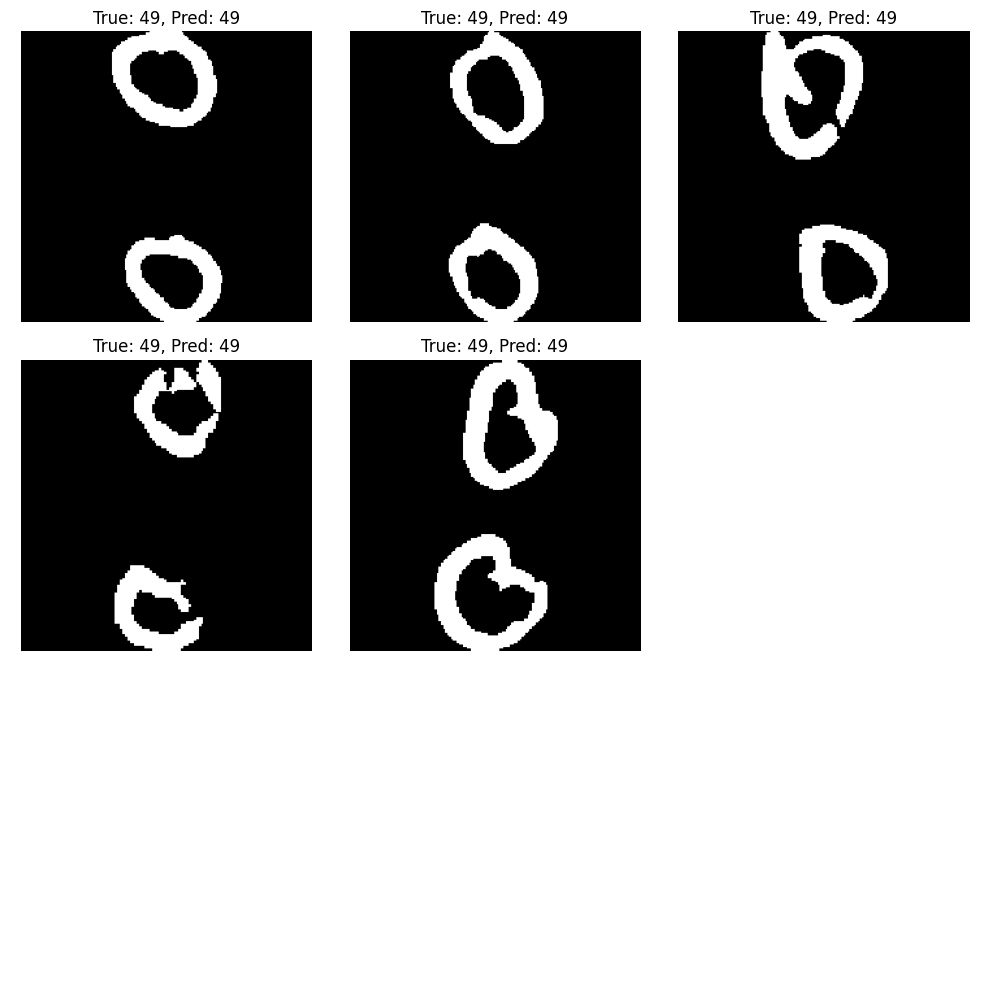

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# NUM_CLASSES, SUPPORT_SIZE, QUERY_SIZE
NUM_CLASSES = 5
SUPPORT_SIZE = 5
QUERY_SIZE = 5

# Call create_few_shot_batches
support_images, support_labels, query_images, query_labels = create_few_shot_batches(
    images, labels, NUM_CLASSES, SUPPORT_SIZE, QUERY_SIZE
)

# Compute prototypes using the support set
prototypes = compute_prototypes(support_images.reshape(-1, 224, 224, 3), support_labels.flatten(), embedding_model)

# Predict on the query set
predictions = predict_query_images(query_images.reshape(-1, 224, 224, 3), prototypes, embedding_model)

# Calculate accuracy
accuracy = np.mean(predictions == query_labels.flatten())
print(f'Few-shot learning accuracy: {accuracy * 100:.2f}%')

# Print predicted and true characters for each query image
for i in range(len(predictions)):
    predicted_class = class_names[predictions[i]]
    true_class = class_names[query_labels.flatten()[i]]
    print(f"Query image {i + 1}: Predicted - {predicted_class}, True - {true_class}")

# Visualize some query images and their predicted labels
def visualize_predictions(query_images, predictions, true_labels, class_names):
    # Get the number of query images to visualize
    num_images = query_images.shape[0]

    # Calculate the grid dimensions (e.g., 3x3, 2x4, etc.)
    grid_size = int(np.ceil(np.sqrt(num_images)))

    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))

    # Flatten the axes for easy iteration
    axes = axes.flatten()

    # Iterate through the query images and plot them
    for i in range(num_images):
        axes[i].imshow(query_images[i])
        axes[i].set_title(f'True: {class_names[true_labels[i]]}, Pred: {class_names[predictions[i]]}')
        axes[i].axis('off')

    # Hide any unused subplots
    for i in range(num_images, len(axes)):
        axes[i].axis('off')

    plt.tight_layout() # Adjust subplot parameters for a tight layout
    plt.show()

# Assuming query_images has shape (num_classes, query_size, 224, 224, 3)
# Get all query images for the first class
query_images_first_class = query_images[0]
# Get the corresponding predictions and true labels for the first class
predictions_first_class = predictions[:QUERY_SIZE]
true_labels_first_class = query_labels[0].flatten()[:QUERY_SIZE]

# Visualize the predictions for the first class
visualize_predictions(query_images_first_class, predictions_first_class, true_labels_first_class, class_names)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


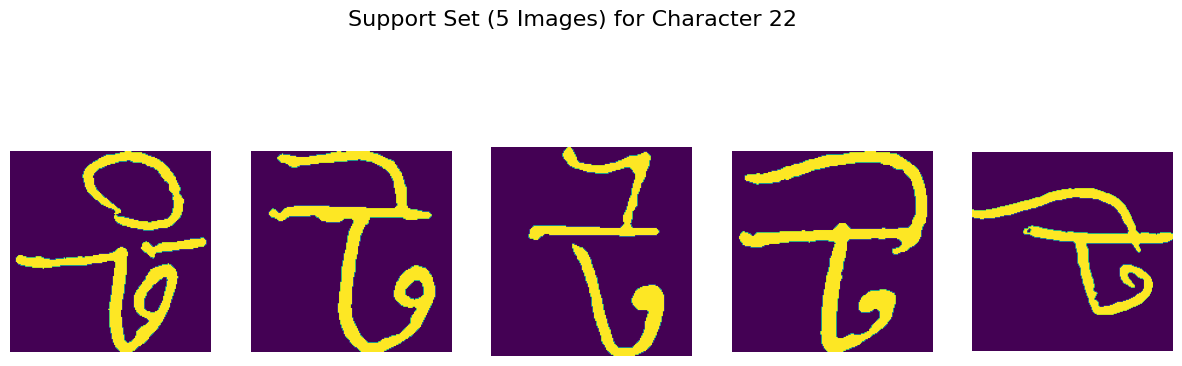

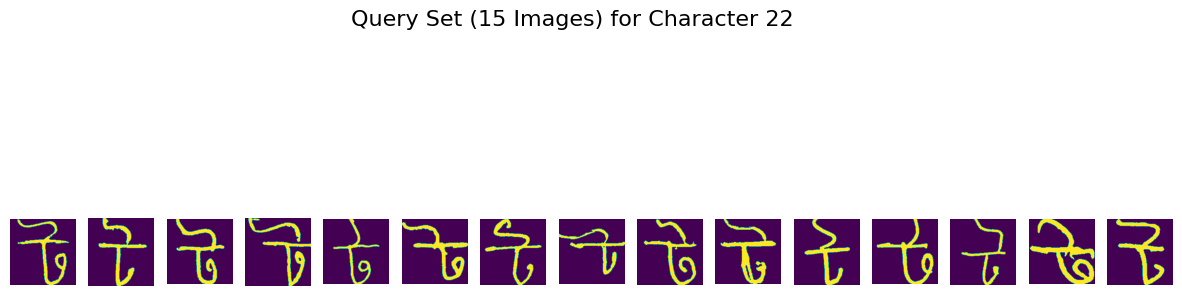

In [11]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import drive # Import the drive module

# Mount Google Drive
drive.mount('/content/drive') # Mount your Google Drive

# Function to load images from a specific character folder
def load_images_from_folder(folder, num_images):
    images = []
    # Check if the folder exists before proceeding
    if not os.path.exists(folder):
        print(f"Error: Folder not found: {folder}")
        return images  # Return empty list if folder doesn't exist

    # Iterate through files in the folder, checking for image extensions
    for filename in os.listdir(folder):
        if filename.endswith(('.png', '.jpg', '.jpeg')):  # Add image extensions here
            img_path = os.path.join(folder, filename)
            img = Image.open(img_path)
            images.append(img)
            if len(images) == num_images:
                break

    return images

# Folder path for character 12 (modify this path as per your dataset structure)
character_22_folder = '/content/drive/MyDrive/new dataset/22' # Verify the path again

# 1. Verify Path: Double-check this path for typos or incorrect folder names
#    You can use the file explorer in Colab to navigate to your Google Drive
#    and ensure the path is accurate.

# 2. Ensure Mounted: Make sure you have mounted your Google Drive using
#    `drive.mount('/content/drive')` before running this code.

# Shuffle the images randomly
all_images = load_images_from_folder(character_22_folder, 20)
random.shuffle(all_images)

# Check if any images were loaded
if not all_images:
    print(f"Warning: No images loaded from folder: {character_22_folder}")
    # Add logic here to handle the case of no images, e.g., exit or use default images
else:
    # Split into support set (5 images) and query set (15 images)
    support_set = all_images[:5]
    query_set = all_images[5:]

    # Function to plot images
    def plot_images(images, title):
        # Ensure that 'images' is not empty before plotting
        if images:
            fig, axes = plt.subplots(1, len(images), figsize=(15, 5))
            fig.suptitle(title, fontsize=16)
            for i, img in enumerate(images):
                axes[i].imshow(img)
                axes[i].axis('off')
            plt.show()
        else:
            print(f"Warning: No images to plot for '{title}'.")

    # Plot the support set
    plot_images(support_set, 'Support Set (5 Images) for Character 22')

    # Plot the query set
    plot_images(query_set, 'Query Set (15 Images) for Character 22')

Epoch 1/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 144s 4s/step - accuracy: 0.0067 - loss: 4.4286 - val_accuracy: 0.0484 - val_loss: 4.1540
Epoch 2/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 143s 4s/step - accuracy: 0.0595 - loss: 4.1384 - val_accuracy: 0.1003 - val_loss: 4.0304
Epoch 3/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 143s 4s/step - accuracy: 0.1339 - loss: 3.9944 - val_accuracy: 0.1730 - val_loss: 3.9134
Epoch 4/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 142s 4s/step - accuracy: 0.2128 - loss: 3.8793 - val_accuracy: 0.2491 - val_loss: 3.8059
Epoch 5/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 140s 4s/step - accuracy: 0.2742 - loss: 3.7509 - val_accuracy: 0.3495 - val_loss: 3.7057
Epoch 6/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 140s 4s/step - accuracy: 0.3176 - loss: 3.6436 - val_accuracy: 0.3599 - val_loss: 3.6097
Epoch 7/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 142s 4s/step - accuracy: 0.4025 - loss: 3.5469 - val_accuracy: 0.4221 - val_loss: 3.5207
Epoch 8/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 140s 4s/step - accuracy: 0.4964 - loss: 3.4365 - val_accuracy: 0.4291 - v

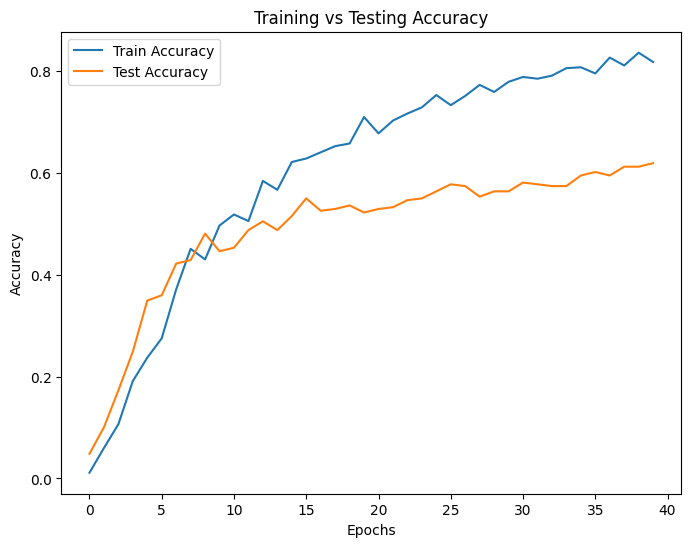

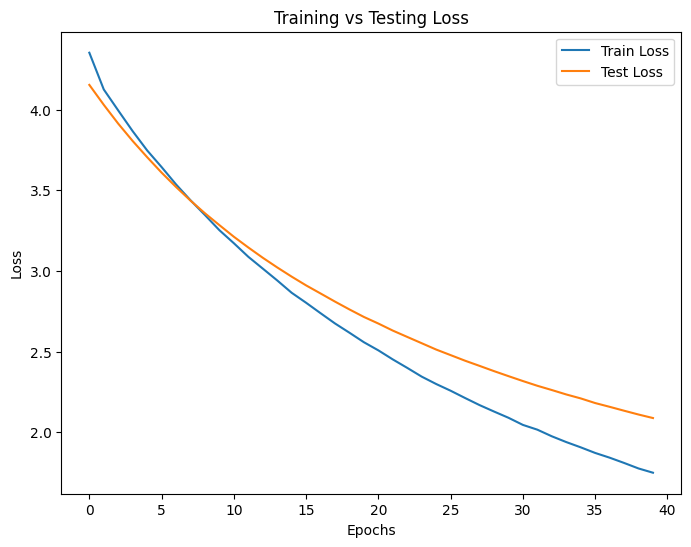

In [12]:
import tensorflow as tf
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import os
import numpy as np

# Parameters
IMAGE_SIZE = (224, 224)
NUM_CLASSES = 72  # Number of classes in your dataset
DATA_PATH = '/content/drive/MyDrive/new dataset'  # Path to your dataset

# Define the embedding model using VGG16
def create_embedding_model(input_shape):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze VGG16 layers
    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)  # Add a final classification layer
    model = Model(inputs, outputs)
    return model

embedding_model = create_embedding_model(IMAGE_SIZE + (3,))

# Compile the model
embedding_model.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

# Load and preprocess the data
def load_images(data_path, img_size):
    images = []
    labels = []
    class_names = os.listdir(data_path)
    for idx, class_name in enumerate(class_names):
        class_dir = os.path.join(data_path, class_name)
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
            img_array = tf.keras.preprocessing.image.img_to_array(img)
            images.append(img_array)
            labels.append(idx)
    return np.array(images), np.array(labels)

# Assuming you have train and test split logic here
images, labels = load_images(DATA_PATH, IMAGE_SIZE)
images = images / 255.0  # Normalize images

train_images, test_images, train_labels, test_labels = train_test_split(images, labels, test_size=0.2, stratify=labels)

# Train the model for 40 epochs
history = embedding_model.fit(
    train_images, train_labels,
    validation_data=(test_images, test_labels),
    epochs=40,
    batch_size=32
)

# Plot Training vs Testing Accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Training vs Testing Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot Training vs Testing Loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Training vs Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


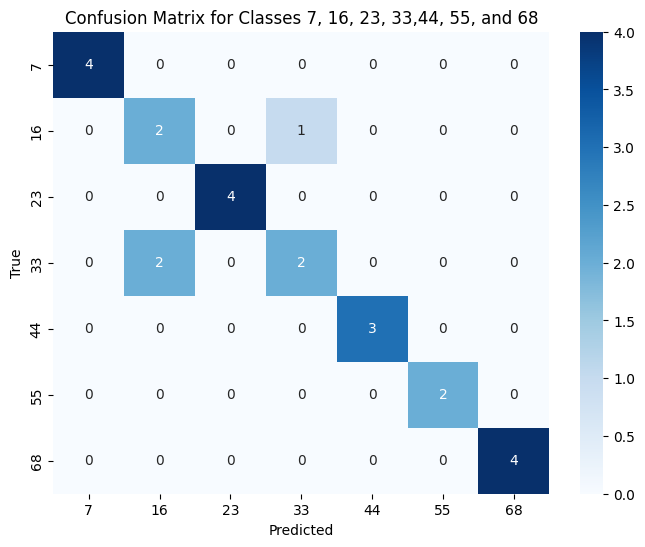

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Select only the classes 7, 16, 23, 33, 44, 55, and 68
selected_classes = [7, 16, 23, 33, 44, 55, 68]

# Get indices for test samples that belong to the selected classes
selected_indices = np.isin(test_labels, selected_classes)

# Subset the test images and labels to only include the selected classes
subset_test_images = test_images[selected_indices]
subset_test_labels = test_labels[selected_indices]

# Ensure 5 test samples per class
subset_test_images_5 = []
subset_test_labels_5 = []

for class_label in selected_classes:
    class_indices = np.where(subset_test_labels == class_label)[0][:5]  # Get the first 5 samples for each class
    subset_test_images_5.append(subset_test_images[class_indices])
    subset_test_labels_5.append(subset_test_labels[class_indices])

# Convert lists to numpy arrays
subset_test_images_5 = np.concatenate(subset_test_images_5)
subset_test_labels_5 = np.concatenate(subset_test_labels_5)

# Predict labels for the subset
subset_predictions = embedding_model.predict(subset_test_images_5)
subset_predicted_labels = np.argmax(subset_predictions, axis=1)

# Create confusion matrix for the selected classes
cm = confusion_matrix(subset_test_labels_5, subset_predicted_labels, labels=selected_classes)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=selected_classes, yticklabels=selected_classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Classes 7, 16, 23, 33,44, 55, and 68')
plt.show()

In [14]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Assuming 'test_labels' contains the true labels and you need to predict labels for the test data
# ... (your code to load and preprocess test data) ...

# Predict labels for the test data using your model
query_predicted_labels = embedding_model.predict(test_images)  # Assuming embedding_model is your trained model
query_predicted_labels = np.argmax(query_predicted_labels, axis=1)  # Get the class with highest probability

# Calculate accuracy
accuracy = accuracy_score(test_labels, query_predicted_labels)
print(f"Accuracy: {accuracy:.4f}")

# Calculate precision, recall, and F1-score
precision = precision_score(test_labels, query_predicted_labels, average='weighted')
recall = recall_score(test_labels, query_predicted_labels, average='weighted')
f1 = f1_score(test_labels, query_predicted_labels, average='weighted')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Full classification report (includes precision, recall, and F1-score for each class)
print(classification_report(test_labels, query_predicted_labels))

10/10 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step
Accuracy: 0.6194
Precision: 0.6229
Recall: 0.6194
F1-Score: 0.5919
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         4
           1       0.67      0.50      0.57         4
           2       1.00      0.75      0.86         4
           3       1.00      0.25      0.40         4
           4       0.67      1.00      0.80         4
           5       0.40      0.50      0.44         4
           6       0.80      1.00      0.89         4
           7       1.00      1.00      1.00         4
           8       0.33      0.25      0.29         4
           9       0.33      0.25      0.29         4
          10       0.67      0.50      0.57         4
          11       0.57      1.00      0.73         4
          12       0.57      1.00      0.73         4
          13       0.00      0.00      0.00         4
          14       0.60      0.75      0.67         4
          15       0.33      

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m